In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split, GridSearchCV
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import numpy as np

In [2]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop="first")

In [3]:
# Helper functions
def box_plot(feature_col, outcome_col, title=""):
    assert len(feature_col) == len(outcome_col)
    groups = [g.values for _, g in feature_col.groupby(outcome_col)]
    labels = list(feature_col.groupby(outcome_col).groups.keys())

    plt.figure(figsize=(8, 6))
    plt.boxplot(groups, tick_labels=labels)
    plt.title(title)
    plt.ylabel(feature_col.name)
    plt.xlabel(outcome_col.name)
    plt.show()

def histogram_plot(feature):
    plt.figure(figsize=(6, 3))
    lower = feature.quantile(0.01)
    upper = feature.quantile(0.99)
    plt.hist(feature, bins="auto", range=(lower, upper))

    skewness=feature.skew()
    kurtosis=feature.kurt()
    plt.title(feature.name)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.text(0.95, 0.95, f"Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}", transform=plt.gca().transAxes, ha="right", va="top")
    plt.show()

def bar_plot(feature):
    counts = feature.value_counts().sort_index()
    plt.figure(figsize=(6, 3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(feature.name)
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def scatter_plot(feature1, feature2):
    assert len(feature1) == len(feature2)
    plt.scatter(feature1, feature2)
    plt.show()

def categorical_plot(categories, rates, title):
    plt.figure()
    plt.bar(categories, rates)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_pred_vs_true(y_test, preds):
    MIN_VALUE = 0
    MAX_VALUE = max(y_test)
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, preds)
    plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")

    plt.title("Predicted vs. True Plot")
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.tight_layout()

def plot_residual(y_test, preds):
    residuals = y_test - preds
    plt.figure(figsize=(8, 8))
    plt.xlabel('Price')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.scatter(preds, residuals)
    plt.axhline(0, linestyle="--")

def get_z_score_scale(dataset, feature_name):
    feature = list(dataset[feature_name])
    mu = np.mean(feature)
    std = np.std(feature)
    return mu, std

def z_score_scale(dataset, feature_name, mu, std):
    dataset[feature_name] = [round((i - mu) / std, 2) for i in dataset[feature_name]]

# Helper functions - Data imputation:
def get_mode(dataset, feature_name):
    mode = dataset[feature_name].mode()
    return mode.iloc[0] if not mode.empty else "unknown"

def get_mean(dataset, feature_name):
    return round(np.nanmean(dataset[feature_name]), 1)

def fill_value(dataset, feature_name, value):
    dataset[feature_name] = dataset[feature_name].fillna(value)

# Helper functions - Conversion
def category_to_num(dataset, feature_name):
    feature = list(dataset[feature_name])
    elements = set(feature)
    
    categories = {}
    for i, e in enumerate(elements):
        if not categories.get(e):
            categories[e] = float(i)

    for i, e in enumerate(feature):
        feature[i] = categories[e]
    
    dataset[feature_name] = feature

def remove_row_due_missing_element(dataset, feature_name):
    return dataset.dropna(subset=[feature_name])

def one_hot_encode_train_test(X_train, X_test, feature_name):
    train_feature = X_train[[feature_name]]
    test_feature = X_test[[feature_name]]

    encoder.fit(train_feature)

    encoded_columns = encoder.get_feature_names_out([feature_name])

    train_encoded = encoder.transform(train_feature)
    test_encoded = encoder.transform(test_feature)

    train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_columns, index=X_train.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_columns, index=X_test.index)

    X_train = pd.concat([X_train.drop(columns=[feature_name]), train_encoded_df], axis=1)

    X_test = pd.concat([X_test.drop(columns=[feature_name]), test_encoded_df], axis=1)

    return X_train, X_test

In [4]:
def log_scale(feature):
    return np.log1p(feature)

def standard_scale(feature, mu=None, std=None):
    if mu == None or std == None:
        mu = np.mean(feature)
        std = np.std(feature)
    feature = [(i - mu) / std for i in feature]
    return feature, mu, std
 
def robust_scale(feature, median=None, iqr=None):
    if median == None or iqr == None:
        q1 = feature.quantile(0.25)
        median = feature.quantile(0.50)
        q3 = feature.quantile(0.75)
        iqr = q3 - q1
    if iqr == 0:
        raise ValueError("IQR is 0, Robust scaler cannot scale this feature")
    feature = (feature - median) / iqr
    return feature, median, iqr

In [5]:
def precision(y_test, y_true):
    assert len(y_test) == len(y_true)
    TP, FP, FN, TN = 0, 0, 0, 0
    for y_hat, y in zip(y_test, y_true):
        if y_hat == "yes" and y == "yes":
            TP += 1
        elif y_hat == "yes" and y == "no":
            FP += 1
        elif y_hat == "no" and y == "yes":
            FN += 1
        else:
            TN += 1
    precision = TP / (TP + FP)
    return precision

def recall(y_test, y_true):
    assert len(y_test) == len(y_true)
    TP, FP, FN, TN = 0, 0, 0, 0
    for y_hat, y in zip(y_test, y_true):
        if y_hat == "yes" and y == "yes":
            TP += 1
        elif y_hat == "yes" and y == "no":
            FP += 1
        elif y_hat == "no" and y == "yes":
            FN += 1
        else:
            TN += 1
    recall = TP / (TP + FN)
    return recall

In [6]:
class ModelHandler:

    def __init__(self):
        self.model = LogisticRegression(max_iter=1000)

    def predict(self, probs, threshold):
        preds = []
        for _, p in enumerate(probs):
            if p[1] >= threshold:
                preds.append('yes')
            else:
                preds.append('no')
        return preds


In [7]:
dataset = pd.read_csv("../bank-full.csv", sep=";")
dataset = dataset.drop(columns=["duration"])
independent_variables = dataset.drop(columns=["y"])
dependent_variable = dataset["y"]
seed = 42
test_size = 0.2
shuffle = True

In [8]:
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=test_size, shuffle=shuffle, stratify=dependent_variable)

In [9]:
categorical_features = X_train.select_dtypes(include=["object", "str"]).columns
numerical_features = X_train.select_dtypes(include=["number"]).columns

In [10]:
categorical_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')

In [11]:
numerical_features

Index(['age', 'balance', 'day', 'campaign', 'pdays', 'previous'], dtype='str')

In [12]:
# We can easily one-hot encode all categorical features.
for f in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train=X_train, X_test=X_test, feature_name=str(f))

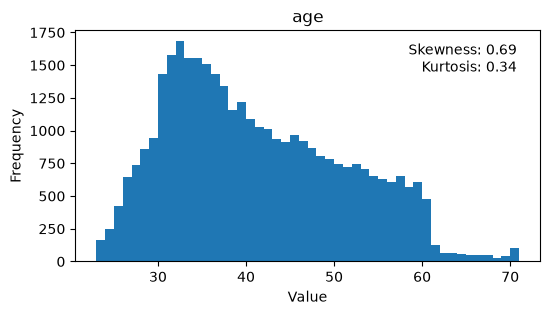

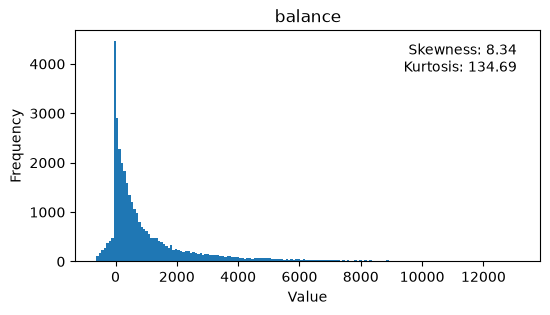

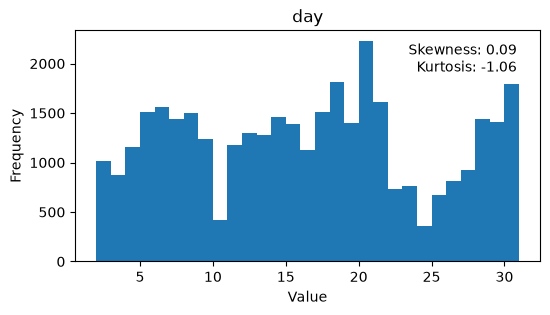

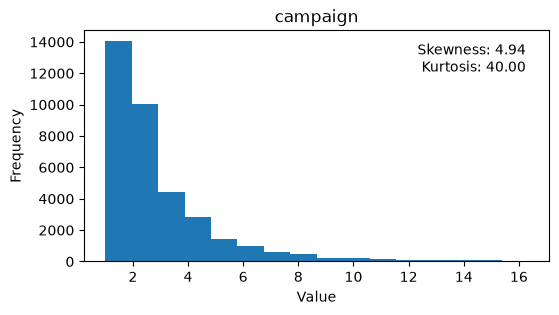

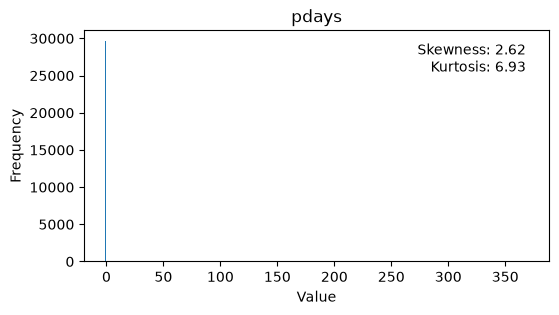

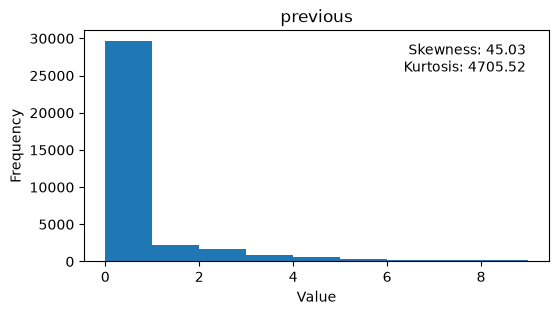

In [13]:
# For numerical features, first I need to visualize their distribution.
for f in numerical_features:
    histogram_plot(X_train[str(f)])

0


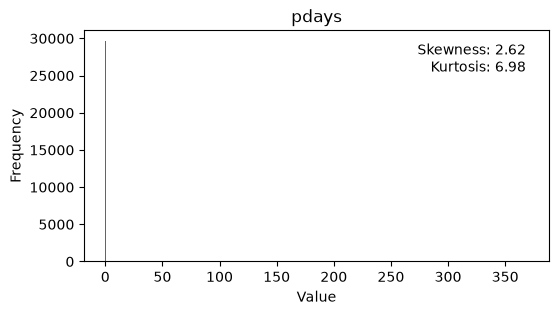

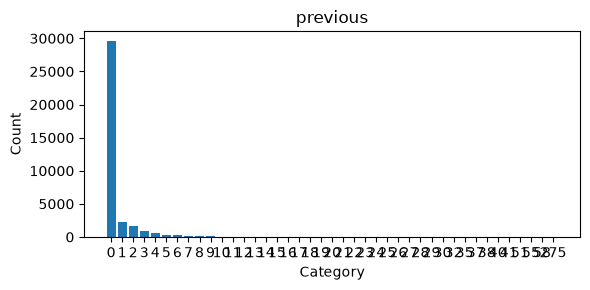

In [14]:
# Pdays misleading here. -1 has different semantic meaning compared to the rest. The best would be to fix this feature semantic meaning. We already have 'previous' feature which contains
# the number of previous contacts, therefore we can't swap -1 to 0 if there is 0 in the feature.

# lets check that first:
print((dataset["pdays"] == 0).sum())

# There is no any 0 in the dataset, so we can avoid collision to an existing value in the dataset.
for df in [X_train, X_test]:
    df["pdays"] = df["pdays"].replace(-1, 0)
histogram_plot(X_train["pdays"])
bar_plot(X_train["previous"])

In [15]:
# Which features are roughly symmetric, which are skewed, and which have heavy tails/outliers? Deciding these will help to decide the scalers.
# roughly simmetric: day, age
# skewed: balance, campaign, previous
# heavy outliers: balance
# special: pdays

In [16]:
# Age: Does not have heavy outliers, therefore standardscaler is good.
# Balance: It has huge outliers. Also there are negative balances, but its not so heavily skewed there. To reduce the outlier factor, I would use robust scaler. 
# We need those outliers, because those are not anomalies.
# Day: Days have equal meanings, therefore standard scaler is good.
# Campaign: Many elements around zero, one, two, three are present, therefore if standardscaler using mean and std, the 16 value would misalign. Therefore we need robust scaler.
# Previous: Robust scaler cannot be used here, due to heavy zero value amount. I will use log1p.
# PDays: Log scaling -> close gaps are more meaningful than later ones. Then maybe standard scaler if needed.

In [17]:
scales = {}
for f in ["age", "day"]:
    X_train[f], mu, std = standard_scale(X_train[f])
    scales[f] = (mu, std)

for f in ["balance", "campaign"]:
    X_train[f], median, iqr = robust_scale(X_train[f])
    scales[f] = (median, iqr)

X_train["previous"] = log_scale(X_train["previous"])
X_train["pdays"] = log_scale(X_train["pdays"])

X_test["previous"] = log_scale(X_test["previous"])
X_test["pdays"] = log_scale(X_test["pdays"])

In [18]:
for f in ["age", "day"]:
    scale = scales[f]
    mu, std = scale[0], scale[1]
    X_test[f], _, _ = standard_scale(X_test[f], mu=mu, std=std)

for f in ["balance", "campaign"]:
    scale = scales[f]
    median, iqr = scale[0], scale[1]
    X_test[f], _, _ = robust_scale(X_test[f], median=median, iqr=iqr)


In [19]:
# Checks before train
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())
print(X_train.shape, X_test.shape)

0
0
(36168, 41) (9043, 41)


In [20]:
# Train with logistic regression
model_handler = ModelHandler()
model_handler.model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [21]:
preds = model_handler.model.predict(X_test)
sum(preds == y_test) / len(y_test)

0.8935087913303107

In [22]:
# Accuracy is misleading here, because we have class imbalance. I need to check precision and recall.
# Recall is important, because we can loose potential subscribers, however if precision is too low, then we introduce many false positives. False positive
# here means that we target many customers which we think could subscribe but they won't and then we waste business resources.
prec = precision(preds, y_test)
rec = recall(preds, y_test)
print(prec, rec)

0.6655052264808362 0.18052930056710775


In [23]:
# https://www.geeksforgeeks.org/machine-learning/understanding-the-predictproba-function-in-scikit-learns-svc/
# Get probability estimates for the test set
probabilities = model_handler.model.predict_proba(X_test)

# Display the probability estimates
for i, prob in enumerate(probabilities):
    print(f"Sample {i+1}: Class 0 Probability = {prob[0]:.4f}, Class 1 Probability = {prob[1]:.4f}")

Sample 1: Class 0 Probability = 0.9867, Class 1 Probability = 0.0133
Sample 2: Class 0 Probability = 0.9744, Class 1 Probability = 0.0256
Sample 3: Class 0 Probability = 0.9643, Class 1 Probability = 0.0357
Sample 4: Class 0 Probability = 0.9827, Class 1 Probability = 0.0173
Sample 5: Class 0 Probability = 0.8668, Class 1 Probability = 0.1332
Sample 6: Class 0 Probability = 0.9525, Class 1 Probability = 0.0475
Sample 7: Class 0 Probability = 0.9297, Class 1 Probability = 0.0703
Sample 8: Class 0 Probability = 0.1645, Class 1 Probability = 0.8355
Sample 9: Class 0 Probability = 0.8905, Class 1 Probability = 0.1095
Sample 10: Class 0 Probability = 0.9116, Class 1 Probability = 0.0884
Sample 11: Class 0 Probability = 0.9826, Class 1 Probability = 0.0174
Sample 12: Class 0 Probability = 0.9407, Class 1 Probability = 0.0593
Sample 13: Class 0 Probability = 0.8659, Class 1 Probability = 0.1341
Sample 14: Class 0 Probability = 0.9696, Class 1 Probability = 0.0304
Sample 15: Class 0 Probabilit

In [24]:
# Compare predictions with probability estimates
for i, (pred, prob, y) in enumerate(zip(preds, probabilities, y_test)):
    print(f"Sample {i+1}: Predicted Class = {pred}, True Class = {y} Class 0 Probability = {prob[0]:.4f}, Class 1 Probability = {prob[1]:.4f}")

Sample 1: Predicted Class = no, True Class = no Class 0 Probability = 0.9867, Class 1 Probability = 0.0133
Sample 2: Predicted Class = no, True Class = no Class 0 Probability = 0.9744, Class 1 Probability = 0.0256
Sample 3: Predicted Class = no, True Class = no Class 0 Probability = 0.9643, Class 1 Probability = 0.0357
Sample 4: Predicted Class = no, True Class = no Class 0 Probability = 0.9827, Class 1 Probability = 0.0173
Sample 5: Predicted Class = no, True Class = no Class 0 Probability = 0.8668, Class 1 Probability = 0.1332
Sample 6: Predicted Class = no, True Class = no Class 0 Probability = 0.9525, Class 1 Probability = 0.0475
Sample 7: Predicted Class = no, True Class = no Class 0 Probability = 0.9297, Class 1 Probability = 0.0703
Sample 8: Predicted Class = yes, True Class = yes Class 0 Probability = 0.1645, Class 1 Probability = 0.8355
Sample 9: Predicted Class = no, True Class = no Class 0 Probability = 0.8905, Class 1 Probability = 0.1095
Sample 10: Predicted Class = no, Tr

In [25]:
print(model_handler.model.classes_)

['no' 'yes']


In [26]:
# We have the probabilities from predict_proba, therefore we can adjust threshold and make new predictions
threshold = 0.5
preds = []
for i, p in enumerate(probabilities):
    if p[1] >= threshold:
        preds.append('yes')
    else:
        preds.append('no')


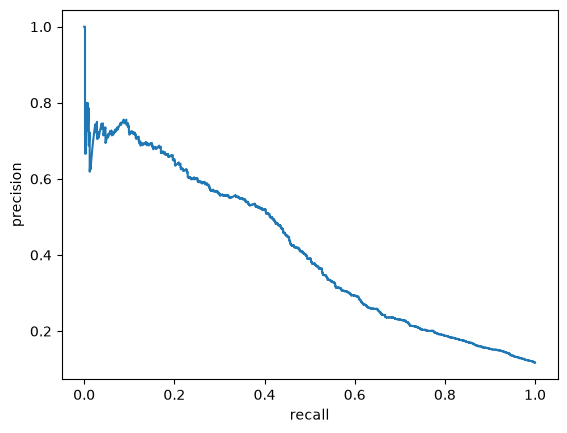

In [27]:
precision, recall, thresholds = precision_recall_curve(y_test, probabilities[:, 1], pos_label="yes")
plt.figure()
plt.plot(recall, precision)
plt.xlabel("recall")
plt.ylabel("precision")
plt.show()

In [28]:
idx = np.argmin(np.abs(recall - 0.4))
print("Threshold:", thresholds[idx])
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Threshold: 0.23660411522485295
Precision: 0.5196560196560197
Recall: 0.3998109640831758


In [29]:
res = model_handler.predict(probabilities, thresholds[idx])
conf_mtx = []
TP, TN, FP, FN = 0, 0, 0, 0
for y_hat, y in zip(res, y_test):
    if y_hat == "yes" and y == "yes":
        TP += 1
    elif y_hat == "yes" and y == "no":
        FP += 1
    elif y_hat == "no" and y == "yes":
        FN += 1
    else:
        TN += 1

conf_mtx = [TP, TN, FP, FN]
prec = TP / (TP + FP)
rec = TP / (TP + FN)
print(conf_mtx, prec, rec)

[423, 7594, 391, 635] 0.5196560196560197 0.3998109640831758


In [30]:
# This is a solid baseline, however moving threshold back and forth won't help our business. If we lower threshold we loose precision significantly, wasting business resources,
# meanwhile if we raise threshold, we loose potential customers. Next, I am going to try out decision tree to make hopefully better predictions.

In [31]:
f1_scorer = make_scorer(f1_score, pos_label="yes")
param_grid = {"max_depth": [3, 5, 7, 10, 15], "min_samples_leaf": [5, 10, 20, 50, 100]}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=param_grid, scoring=f1_scorer, cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...pos_label=yes)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [32]:
print(grid.best_params_)
print(grid.best_score_)
best_tree = grid.best_estimator_

{'max_depth': 15, 'min_samples_leaf': 10}
0.32133604017925144


In [33]:
tree_probs = best_tree.predict_proba(X_test)
best_tree.classes_

array(['no', 'yes'], dtype=object)

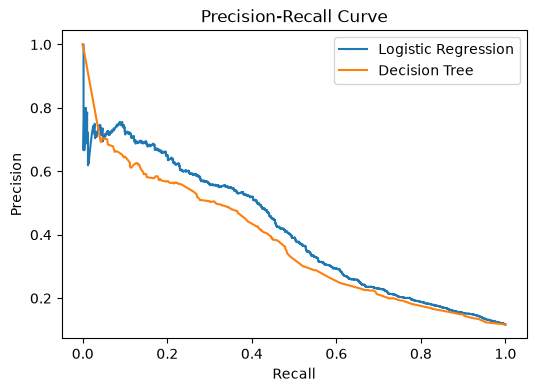

In [34]:
tree_precision, tree_recall, tree_thresholds = precision_recall_curve(
    y_test,
    tree_probs[:, 1],
    pos_label="yes"
)
plt.figure(figsize=(6, 4))

plt.plot(recall, precision, label="Logistic Regression")
plt.plot(tree_recall, tree_precision, label="Decision Tree")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [35]:
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=param_grid, scoring=f1_scorer, cv=5)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...pos_label=yes)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [36]:
best_forest = grid.best_estimator_
forest_probs = best_forest.predict_proba(X_test)
best_forest.classes_

array(['no', 'yes'], dtype=object)

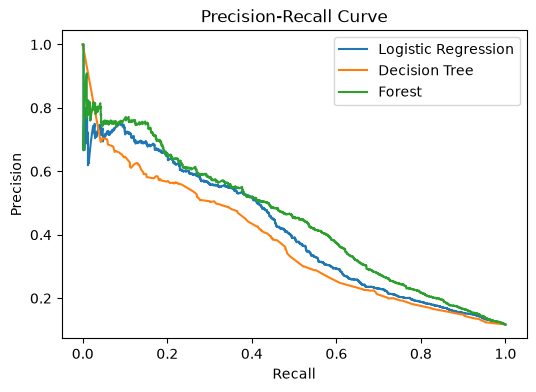

In [37]:
forest_precision, forest_recall, forest_thresholds = precision_recall_curve(
    y_test,
    forest_probs[:, 1],
    pos_label="yes"
)
plt.figure(figsize=(6, 4))

plt.plot(recall, precision, label="Logistic Regression")
plt.plot(tree_recall, tree_precision, label="Decision Tree")
plt.plot(forest_recall, forest_precision, label="Forest")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [38]:
# These outcomes show me a deeper issue with the features, so I need to revisit the dataset and my feature preprocessing.

In [39]:
# And yes... my assumption was right. I have several additional leaky features (bank-names.txt):
#   9 - contact: contact communication type (categorical: "unknown","telephone","cellular") 
#  10 - day: last contact day of the month (numeric)
#  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
#  12 - duration: last contact duration, in seconds (numeric)
   # other attributes:
#  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

# These are leaky features, because we don't know them in prediction time. They include the last contact information which in prediction time not known.

In [40]:
dataset = pd.read_csv("../bank-full.csv", sep=";")
seed = 42
test_size = 0.2
shuffle = True

for feature in ["duration", "contact", "day", "month", "campaign"]:
    dataset = dataset.drop(columns=[feature])

independent_variables = dataset.drop(columns=["y"])
dependent_variable = dataset["y"]
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=test_size, shuffle=shuffle, stratify=dependent_variable)
categorical_features = X_train.select_dtypes(include=["object", "str"]).columns
numerical_features = X_train.select_dtypes(include=["number"]).columns

for f in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train=X_train, X_test=X_test, feature_name=str(f))

scales = {}
for f in ["age"]:
    X_train[f], mu, std = standard_scale(X_train[f])
    scales[f] = (mu, std)

for f in ["balance"]:
    X_train[f], median, iqr = robust_scale(X_train[f])
    scales[f] = (median, iqr)

for df in [X_train, X_test]:
    df["pdays"] = df["pdays"].replace(-1, 0)

for f in ["age"]:
    scale = scales[f]
    mu, std = scale[0], scale[1]
    X_test[f], _, _ = standard_scale(X_test[f], mu=mu, std=std)

for f in ["balance"]:
    scale = scales[f]
    median, iqr = scale[0], scale[1]
    X_test[f], _, _ = robust_scale(X_test[f], median=median, iqr=iqr)

X_train["previous"] = log_scale(X_train["previous"])
X_train["pdays"] = log_scale(X_train["pdays"])

X_test["previous"] = log_scale(X_test["previous"])
X_test["pdays"] = log_scale(X_test["pdays"])

In [41]:
model_handler = ModelHandler()
model_handler.model.fit(X_train, y_train)
probabilities_after_feature_removal = model_handler.model.predict_proba(X_test)
precision_clean, recall_clean, thresholds_clean = precision_recall_curve(y_test, probabilities_after_feature_removal[:, 1], pos_label="yes")

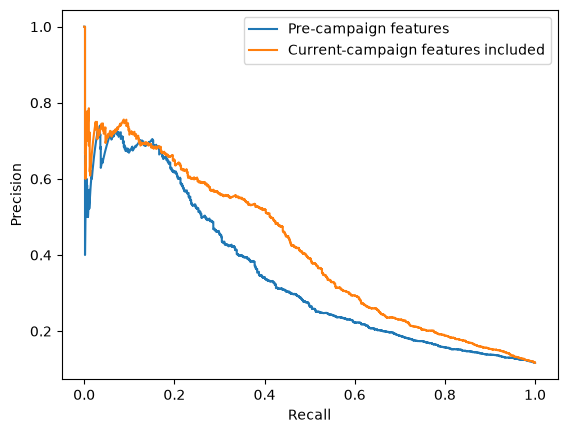

In [42]:
dataset = pd.read_csv("../bank-full.csv", sep=";")
seed = 42
test_size = 0.2
shuffle = True

for feature in ["duration"]:
    dataset = dataset.drop(columns=[feature])

independent_variables = dataset.drop(columns=["y"])
dependent_variable = dataset["y"]
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=test_size, shuffle=shuffle, stratify=dependent_variable)
categorical_features = X_train.select_dtypes(include=["object", "str"]).columns
numerical_features = X_train.select_dtypes(include=["number"]).columns

for f in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train=X_train, X_test=X_test, feature_name=str(f))

scales = {}
for f in ["age"]:
    X_train[f], mu, std = standard_scale(X_train[f])
    scales[f] = (mu, std)

for f in ["balance"]:
    X_train[f], median, iqr = robust_scale(X_train[f])
    scales[f] = (median, iqr)

for df in [X_train, X_test]:
    df["pdays"] = df["pdays"].replace(-1, 0)

for f in ["age"]:
    scale = scales[f]
    mu, std = scale[0], scale[1]
    X_test[f], _, _ = standard_scale(X_test[f], mu=mu, std=std)

for f in ["balance"]:
    scale = scales[f]
    median, iqr = scale[0], scale[1]
    X_test[f], _, _ = robust_scale(X_test[f], median=median, iqr=iqr)

X_train["previous"] = log_scale(X_train["previous"])
X_train["pdays"] = log_scale(X_train["pdays"])

X_test["previous"] = log_scale(X_test["previous"])
X_test["pdays"] = log_scale(X_test["pdays"])

model_handler = ModelHandler()
model_handler.model.fit(X_train, y_train)
probabilities_after_feature_removal = model_handler.model.predict_proba(X_test)
precision_campaign, recall_campaign, thresholds_campaign = precision_recall_curve(y_test, probabilities_after_feature_removal[:, 1], pos_label="yes")
plt.plot(recall_clean, precision_clean, label="Pre-campaign features")
plt.plot(recall_campaign, precision_campaign, label="Current-campaign features included")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [43]:
# This result shows us that the current campaign features performs better, because it contains the leaky features. These variables are unknown in prediction time, therefore 
# I am going to drop them during in the final train.py